# What this notebook is doing (SNOTEL water year analysis)

This notebook looks at SNOTEL precipitation by water year for the Skagit area.
The main goal is to see how the individual SNOTEL stations behave over time and how they group within the Skagit sub-basins.

It pulls the station metadata and daily station CSVs, assigns each station to Upper Skagit, Sauk, or Lower Skagit, and then computes water-year precipitation totals for each station.
After that it saves a station-level CSV and makes one plot per sub-basin, with each station shown as its own line.

This is mainly a station-based SNOTEL summary notebook, not a gridded product comparison notebook.


[SNOTEL] Downloading stations GeoJSON...
[SNOTEL] Stations assigned by region:
  - Upper Skagit: ['Beaver Pass', 'Brown Top', 'Hozomeen Camp', 'Marten Ridge', 'Rainy Pass', 'Swamp Creek', 'Thunder Basin']
  - Sauk: ['Miners Ridge']
  - Lower Skagit: (none)
[SNOTEL] Downloading station CSVs and computing WY totals...
[SNOTEL] Failed to read 991_WA_SNTL (Hozomeen Camp): HTTP Error 404: Not Found
[SNOTEL] Failed to read 630_WA_SNTL (Miners Ridge): HTTP Error 404: Not Found
Saved station-level CSV → /data0/balaji24/data/derived/snotel_station_water_year_precip_by_region_2014_2024.csv
Saved plot → /data0/balaji24/data/derived/snotel_station_wy_precip_Upper_Skagit_2014_2024.png


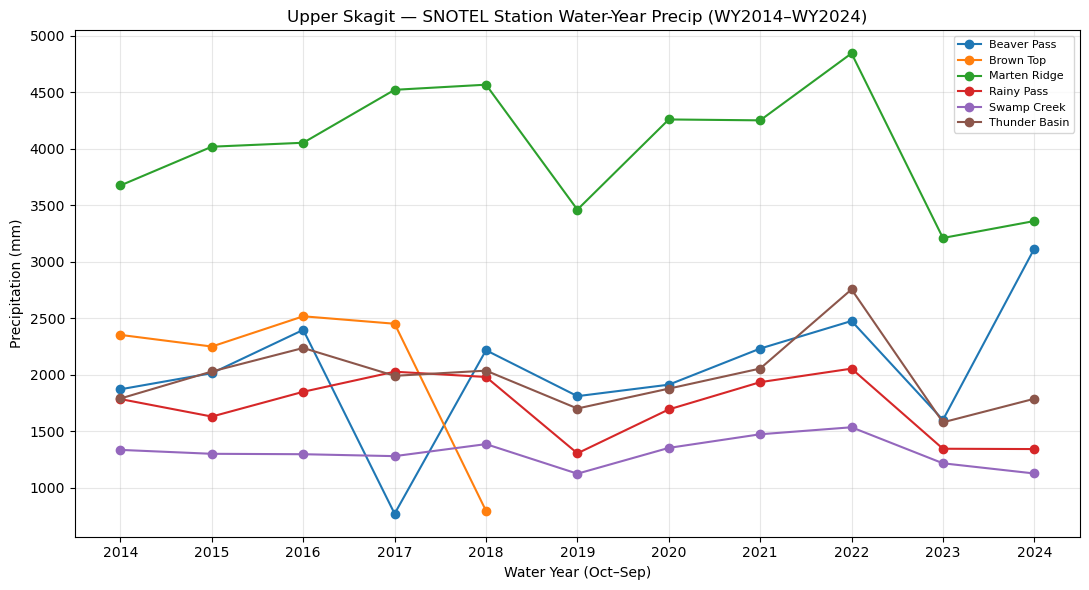

[PLOT] No stations with data for region=Sauk
[PLOT] No stations with data for region=Lower Skagit


In [ ]:
# ============================
# Skagit — SNOTEL WATER YEAR precip (mm) by station, plotted per sub-basin
#   - Upper Skagit 
#   - Sauk        
#   - Lower Skagit
#
# WY: Oct 1 to Sep 30 (labeled by ending year)
# Output:
# - CSV: station-level WY totals with region assignment
# - 3 PNGs: one per sub-basin, lines = stations
# ============================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import geopandas as gpd
import shapely.geometry as sgeom
import requests

# ---------------- Config ----------------
BASE = Path("/data0/balaji24/data")
OUT = BASE / "derived"
OUT.mkdir(parents=True, exist_ok=True)

BOUNDARY_GEO = Path("../data/GIS/SkagitBoundary.json")
HUC8_GEO     = Path("../data/GIS/SkagitSubBasin_HUC8.geojson")

YEAR_MIN, YEAR_MAX = 2014, 2024
REGION_NAMES = ["Upper Skagit", "Sauk", "Lower Skagit"]

CSV_OUT = OUT / f"snotel_station_water_year_precip_by_region_{YEAR_MIN}_{YEAR_MAX}.csv"

STATIONS_URL = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson"
BASE_CSV_URL = "https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/data"

# Optional: restrict to specific station names; set to None to keep all stations inside Skagit
# DESIRED_NAMES = {"Beaver Pass", "Brown Top", "Marten Ridge", "Rainy Pass", "Swamp Creek", "Thunder Basin"}
DESIRED_NAMES = None

# ---------------- Helpers ----------------
def water_year_index(dt_index: pd.DatetimeIndex) -> np.ndarray:
    return np.where(dt_index.month >= 10, dt_index.year + 1, dt_index.year)

def plot_nozero(ax, x, y, *, marker="o", label=None):
    y = pd.Series(y).where(pd.Series(y) != 0, np.nan)
    ax.plot(x, y, marker=marker, label=label)

# ---------------- Load boundary + regions ----------------
skagit = gpd.read_file(BOUNDARY_GEO).to_crs("EPSG:4326")
huc8   = gpd.read_file(HUC8_GEO).to_crs("EPSG:4326")

regions = huc8[huc8["Name"].isin(REGION_NAMES)].copy()
if regions.empty:
    raise ValueError(f"No matching HUC8 regions found for {REGION_NAMES}. Check 'Name' field in {HUC8_GEO}")

regions = gpd.overlay(regions, skagit, how="intersection")
regions = regions[["Name", "geometry"]].reset_index(drop=True)
regions["Name"] = pd.Categorical(regions["Name"], categories=REGION_NAMES, ordered=True)
regions = regions.sort_values("Name").reset_index(drop=True)

skagit_geom = skagit.geometry.iloc[0]

# ---------------- Load stations ----------------
print("[SNOTEL] Downloading stations GeoJSON...")
r = requests.get(STATIONS_URL, timeout=30)
r.raise_for_status()
gj = r.json()

records, geoms = [], []
for feat in gj.get("features", []):
    props = feat.get("properties", {})
    geom = feat.get("geometry")
    if geom is None:
        continue
    records.append(props)
    geoms.append(sgeom.shape(geom))

stations = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326")
if stations.empty:
    raise ValueError("[SNOTEL] No stations found in GeoJSON.")

# stations inside Skagit
stations_skagit = stations[stations.geometry.within(skagit_geom)].copy()
if stations_skagit.empty:
    raise ValueError("[SNOTEL] No stations fell inside Skagit boundary.")

# optional name filter
if DESIRED_NAMES is not None:
    if "name" not in stations_skagit.columns:
        raise ValueError("[SNOTEL] Station GeoJSON missing 'name' field; cannot apply DESIRED_NAMES filter.")
    stations_skagit = stations_skagit[stations_skagit["name"].isin(DESIRED_NAMES)].copy()

if stations_skagit.empty:
    raise ValueError("[SNOTEL] No stations remain after filtering.")

# join stations - regions
try:
    joined = gpd.sjoin(
        stations_skagit,
        regions.rename(columns={"Name": "region"}),
        predicate="within",
        how="left",
    )
except TypeError:
    joined = gpd.sjoin(
        stations_skagit,
        regions.rename(columns={"Name": "region"}),
        op="within",
        how="left",
    )

joined = joined.dropna(subset=["region"]).copy()
if joined.empty:
    raise ValueError("[SNOTEL] Stations found, but none fell within the 3 region polygons.")

print("[SNOTEL] Stations assigned by region:")
for reg in REGION_NAMES:
    sub = joined[joined["region"] == reg]
    names = sub["name"].tolist() if "name" in sub.columns else sub["code"].tolist()
    print(f"  - {reg}: {names if names else '(none)'}")

# ---------------- Compute station-level WY totals ----------------
GLOBAL_START = f"{YEAR_MIN-1}-10-01"
GLOBAL_END   = f"{YEAR_MAX}-09-30"

rows = []
print("[SNOTEL] Downloading station CSVs and computing WY totals...")

for _, row in joined.iterrows():
    code = row.get("code")
    name = row.get("name", code)
    region = str(row["region"])

    if pd.isna(code):
        continue

    csv_url = f"{BASE_CSV_URL}/{code}.csv"
    try:
        df_s = pd.read_csv(csv_url, index_col="datetime", parse_dates=True)
    except Exception as e:
        print(f"[SNOTEL] Failed to read {code} ({name}): {e}")
        continue

    if "PRCPSA" not in df_s.columns:
        print(f"[SNOTEL] No PRCPSA for {code} ({name}), skipping.")
        continue

    precip_mm = (df_s["PRCPSA"] * 1000.0).loc[GLOBAL_START:GLOBAL_END].dropna()
    if precip_mm.empty:
        continue

    wy = water_year_index(precip_mm.index)
    tmp = pd.DataFrame({"mm": precip_mm.values, "wy": wy}, index=precip_mm.index)
    annual = tmp.groupby("wy")["mm"].sum()

    for wy_label, val in annual.items():
        wy_label = int(wy_label)
        if YEAR_MIN <= wy_label <= YEAR_MAX:
            rows.append({
                "region": region,
                "station_code": str(code),
                "station_name": str(name),
                "year": wy_label,
                "mm": float(val),
            })

df_station = pd.DataFrame(rows)
if df_station.empty:
    raise ValueError("[SNOTEL] No station WY totals computed (check time coverage / filtering).")

df_station = df_station.sort_values(["region", "station_name", "year"]).reset_index(drop=True)
df_station.to_csv(CSV_OUT, index=False)
print("Saved station-level CSV →", CSV_OUT)

# ---------------- Plot: one figure per region, lines = stations ----------------
for region in REGION_NAMES:
    sub_r = df_station[df_station["region"] == region].copy()
    if sub_r.empty:
        print(f"[PLOT] No stations with data for region={region}")
        continue

    fig, ax = plt.subplots(figsize=(11, 6))

    for st_name, g in sub_r.groupby("station_name"):
        g = g.sort_values("year")
        plot_nozero(ax, g["year"], g["mm"], marker="o", label=st_name)

    ax.set_title(f"{region} — SNOTEL Station Water-Year Precip (WY{YEAR_MIN}–WY{YEAR_MAX})")
    ax.set_xlabel("Water Year (Oct–Sep)")
    ax.set_ylabel("Precipitation (mm)")
    ax.set_xticks(list(range(YEAR_MIN, YEAR_MAX + 1)))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

    fig.tight_layout()
    out_png = OUT / f"snotel_station_wy_precip_{region.replace(' ','_')}_{YEAR_MIN}_{YEAR_MAX}.png"
    fig.savefig(out_png, dpi=160)
    print("Saved plot →", out_png)
    plt.show()
